In [1]:
from __future__ import annotations

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
np.random.seed(42)

### Carregar dados e funções de limpeza (reutilizadas do EDA)

In [3]:
CANDIDATE_DIRS = [Path("."), Path("data")]


def pick_path(filename: str) -> Path:
    for d in CANDIDATE_DIRS:
        p = d / filename
        if p.exists():
            return p
    return CANDIDATE_DIRS[0] / filename


FLIGHTS_PATH = pick_path("flights.csv")
AIRPORTS_PATH = pick_path("airports.csv")
AIRLINES_PATH = pick_path("airlines.csv")
assert FLIGHTS_PATH.exists(), f"Arquivo não encontrado: {FLIGHTS_PATH.resolve()}"

DELAY_CAUSE_COLS = [
    "AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY",
]


def hhmm_to_minutes(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.nan
    s = str(x).strip().zfill(4)
    if not s.isdigit() or len(s) != 4:
        return np.nan
    hh, mm = int(s[:2]), int(s[2:])
    if not (0 <= hh <= 23 and 0 <= mm <= 59):
        return np.nan
    return hh * 60 + mm


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["scheduled_dep_min"] = df["SCHEDULED_DEPARTURE"].map(hhmm_to_minutes)
    df["scheduled_dep_hour"] = (df["scheduled_dep_min"] // 60).astype("Int64")
    df["scheduled_arr_min"] = df["SCHEDULED_ARRIVAL"].map(hhmm_to_minutes)
    df["scheduled_arr_hour"] = (df["scheduled_arr_min"] // 60).astype("Int64")
    return df


def clean_flights(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    obj_cols = df.select_dtypes(include=["object", "string"]).columns
    if len(obj_cols):
        df[obj_cols] = df[obj_cols].replace({"": pd.NA})
    for c in ["CANCELLED", "DIVERTED"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype("Int8")
    not_cancelled = (df["CANCELLED"] == 0) if "CANCELLED" in df.columns else pd.Series(True, index=df.index)
    present_delay = [c for c in DELAY_CAUSE_COLS if c in df.columns]
    if present_delay:
        df.loc[not_cancelled, present_delay] = df.loc[not_cancelled, present_delay].apply(pd.to_numeric, errors="coerce").fillna(0)
    if "CANCELLATION_REASON" in df.columns and "CANCELLED" in df.columns:
        df.loc[not_cancelled & df["CANCELLATION_REASON"].isna(), "CANCELLATION_REASON"] = "NOT_CANCELLED"
        df.loc[(~not_cancelled) & df["CANCELLATION_REASON"].isna(), "CANCELLATION_REASON"] = "UNKNOWN"
    num_like = ["YEAR", "MONTH", "DAY", "DAY_OF_WEEK", "DISTANCE", "DEPARTURE_DELAY", "ARRIVAL_DELAY", "TAXI_OUT", "TAXI_IN", "AIR_TIME", "ELAPSED_TIME", "SCHEDULED_TIME"]
    for c in [x for x in num_like if x in df.columns]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    if all(c in df.columns for c in ["YEAR", "MONTH", "DAY"]):
        df["date"] = pd.to_datetime({"year": df["YEAR"], "month": df["MONTH"], "day": df["DAY"]}, errors="coerce")
    return add_time_features(df)


def load_sample(path: Path, chunksize=250_000, frac_per_chunk=0.03, max_rows=400_000, seed=42):
    rng = np.random.default_rng(seed)
    samples = []
    for chunk in pd.read_csv(path, chunksize=chunksize):
        s = chunk.sample(frac=frac_per_chunk, random_state=int(rng.integers(0, 2**31 - 1)))
        samples.append(s)
        if sum(len(x) for x in samples) >= max_rows:
            break
    df = pd.concat(samples, ignore_index=True)
    if len(df) > max_rows:
        df = df.sample(n=max_rows, random_state=seed).reset_index(drop=True)
    return clean_flights(df)


df = load_sample(FLIGHTS_PATH)
print("Shape:", df.shape)

Shape: (174572, 36)


### Definir target e filtrar dados para classificação

In [4]:
# Só voos realizados (não cancelados, não desviados)
mask_ok = (df["CANCELLED"] == 0) & (df["DIVERTED"] == 0)
df_ok = df.loc[mask_ok].copy()

# Target: atraso na chegada > 15 minutos
MIN_DELAY_MINUTES = 15
df_ok["atrasado"] = (df_ok["ARRIVAL_DELAY"] > MIN_DELAY_MINUTES).astype(int)

# Remover linhas onde ARRIVAL_DELAY é NaN
df_ok = df_ok.dropna(subset=["ARRIVAL_DELAY", "atrasado"])

print("Proporção de voos atrasados (target=1):", round(float(df_ok["atrasado"].mean()), 3))
print("Contagem:", df_ok["atrasado"].value_counts().to_dict())

Proporção de voos atrasados (target=1): 0.18
Contagem: {0: 140625, 1: 30768}


### Features disponíveis antes do voo (treino)

In [5]:
#features sem atraso real
FEATURES_CAT = ["AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]
FEATURES_NUM = ["MONTH", "DAY", "DAY_OF_WEEK", "scheduled_dep_hour", "DISTANCE", "SCHEDULED_TIME"]
TARGET = "atrasado"

all_feature_cols = FEATURES_CAT + FEATURES_NUM
for c in all_feature_cols:
    if c not in df_ok.columns:
        raise ValueError(f"Coluna ausente: {c}")

# Remover linhas com NaN nas features (para treino estável)
df_model = df_ok.dropna(subset=all_feature_cols + [TARGET]).copy()
for c in FEATURES_CAT:
    df_model[c] = df_model[c].astype(str)
X = df_model[all_feature_cols]
y = df_model[TARGET]

print("Amostras para treino:", len(X))
print("Features:", all_feature_cols)

Amostras para treino: 171393
Features: ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'scheduled_dep_hour', 'DISTANCE', 'SCHEDULED_TIME']


### Pipeline: codificação + modelo

In [7]:
preprocessor = ColumnTransformer(
    [
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), FEATURES_CAT),
        ("num", StandardScaler(), FEATURES_NUM),
    ],
    remainder="drop",
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Random Forest
model_rf = Pipeline([("prep", preprocessor), ("clf", RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42))])
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print("Acurácia:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf, zero_division=0), 4))
print("F1:", round(f1_score(y_test, y_pred_rf, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 4))

=== Random Forest ===
Acurácia: 0.8205
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC-AUC: 0.6465


In [8]:
# Regressão Logística (comparação)
model_lr = Pipeline([("prep", preprocessor), ("clf", LogisticRegression(max_iter=500, random_state=42))])
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
y_proba_lr = model_lr.predict_proba(X_test)[:, 1]

print("=== Regressão Logística ===")
print("Acurácia:", round(accuracy_score(y_test, y_pred_lr), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, y_pred_lr, zero_division=0), 4))
print("F1:", round(f1_score(y_test, y_pred_lr, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_lr), 4))

=== Regressão Logística ===
Acurácia: 0.8205
Precision: 0.5
Recall: 0.0022
F1: 0.0044
ROC-AUC: 0.6327


### Matriz de confusão (Random Forest)

Matplotlib is building the font cache; this may take a moment.


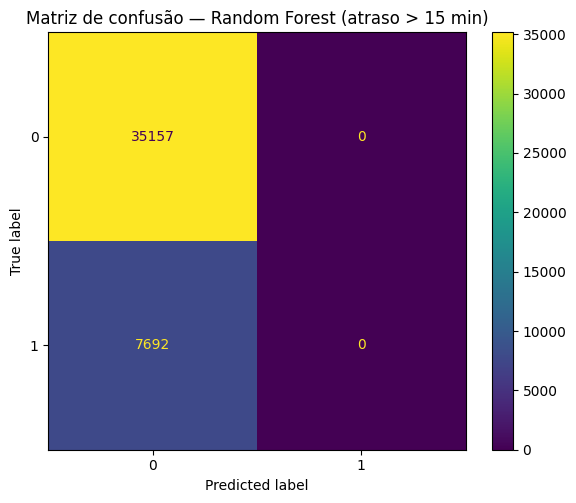

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax, colorbar=True)
ax.set_title("Matriz de confusão — Random Forest (atraso > 15 min)")
plt.tight_layout()
plt.show()

### Validação cruzada (RF)

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model_rf, X, y, cv=cv, scoring="roc_auc")
print("ROC-AUC (CV 5-fold):", [round(s, 4) for s in scores])
print("Média:", round(float(scores.mean()), 4), "±", round(float(scores.std()), 4))

ROC-AUC (CV 5-fold): [np.float64(0.6528), np.float64(0.6418), np.float64(0.6574), np.float64(0.643), np.float64(0.6432)]
Média: 0.6477 ± 0.0063


### Características que aumentam a chance de atraso

Análise com base na **importância das variáveis** do Random Forest e na **taxa de atraso observada** nos dados.

Importância agregada por variável (maior = mais associada ao atraso):
       var_original  importance
 scheduled_dep_hour    0.219483
DESTINATION_AIRPORT    0.140225
     ORIGIN_AIRPORT    0.134974
            AIRLINE    0.130146
              MONTH    0.123437
                DAY    0.090906
     SCHEDULED_TIME    0.071854
        DAY_OF_WEEK    0.066130
           DISTANCE    0.022844


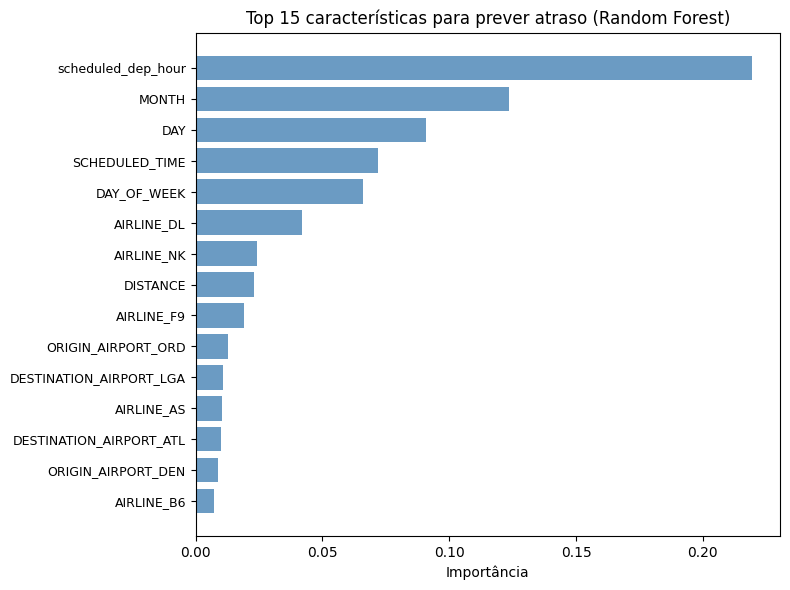

In [14]:
# Importância das variáveis no Random Forest
prep = model_rf.named_steps["prep"]
clf = model_rf.named_steps["clf"]
feature_names = prep.get_feature_names_out()
importances = clf.feature_importances_
imp_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

def var_original(name):
    s = name.replace("cat__", "").replace("num__", "")
    if name.startswith("cat__"):
        return s.rsplit("_", 1)[0]  # AIRLINE_NK -> AIRLINE, ORIGIN_AIRPORT_IAH -> ORIGIN_AIRPORT
    return s

imp_df["var_original"] = imp_df["feature"].apply(var_original)
imp_por_var = imp_df.groupby("var_original", as_index=False)["importance"].sum().sort_values("importance", ascending=False)
print("Importância agregada por variável (maior = mais associada ao atraso):")
print(imp_por_var.to_string(index=False))

# Gráfico das 15 features mais importantes (nível one-hot)
fig, ax = plt.subplots(figsize=(8, 6))
top = imp_df.head(15)
ax.barh(range(len(top)), top["importance"].values, color="steelblue", alpha=0.8)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top["feature"].str.replace("cat__|num__", "", regex=True), fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Importância")
ax.set_title("Top 15 características para prever atraso (Random Forest)")
plt.tight_layout()
plt.show()

In [13]:
# Taxa de atraso observada nos dados (o que realmente aumenta a chance de atraso)
print("=== Taxa de atraso por companhia aérea (top 10 com mais voos) ===\n")
por_companhia = df_model.groupby("AIRLINE").agg(
    voos=("atrasado", "count"),
    taxa_atraso=("atrasado", "mean"),
).sort_values("voos", ascending=False)
por_companhia["taxa_%"] = (por_companhia["taxa_atraso"] * 100).round(1)
print(por_companhia.head(10).to_string())

print("\n=== Taxa de atraso por horário de partida programado (hora) ===\n")
por_hora = df_model.groupby("scheduled_dep_hour").agg(
    voos=("atrasado", "count"),
    taxa_atraso=("atrasado", "mean"),
).reset_index()
por_hora["taxa_%"] = (por_hora["taxa_atraso"] * 100).round(1)
print(por_hora.to_string(index=False))

print("\n=== Taxa de atraso por dia da semana ===\n")
por_dia = df_model.groupby("DAY_OF_WEEK").agg(
    voos=("atrasado", "count"),
    taxa_atraso=("atrasado", "mean"),
).reset_index()
por_dia["taxa_%"] = (por_dia["taxa_atraso"] * 100).round(1)
print(por_dia.to_string(index=False))

=== Taxa de atraso por companhia aérea (top 10 com mais voos) ===

          voos  taxa_atraso  taxa_%
AIRLINE                            
WN       37245     0.183676    18.4
DL       26111     0.124009    12.4
AA       21497     0.180816    18.1
OO       17015     0.181604    18.2
EV       16605     0.192894    19.3
UA       15263     0.194326    19.4
MQ        8446     0.210514    21.1
B6        7918     0.216343    21.6
US        5972     0.180342    18.0
AS        5071     0.130941    13.1

=== Taxa de atraso por horário de partida programado (hora) ===

 scheduled_dep_hour  voos  taxa_atraso  taxa_%
                  0   439     0.182232    18.2
                  1   147     0.142857    14.3
                  2    37     0.135135    13.5
                  3    12     0.250000    25.0
                  4    16     0.125000    12.5
                  5  3475     0.080288     8.0
                  6 11804     0.083785     8.4
                  7 11535     0.109840    11.0
            

## Respostas às perguntas de análise

1. **Os atrasos são mais comuns em certos dias da semana ou horários?**
2. **É possível agrupar aeroportos com perfis semelhantes?**
3. **Até que ponto conseguimos prever atrasos com base no histórico e contexto do voo?**

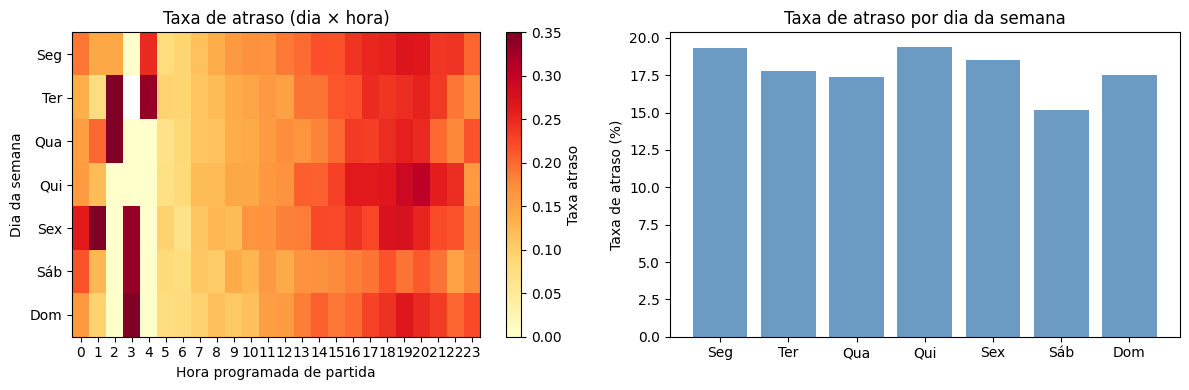

Conclusão: Sim. Atrasos variam por dia da semana e por horário.
Horários de pico (manhã e fim de tarde) e certos dias (ex.: sexta/domingo) tendem a ter maior taxa.


In [14]:
# 1) Atrasos por dia da semana e horário
por_dia = df_model.groupby("DAY_OF_WEEK").agg(
    voos=("atrasado", "count"),
    taxa_atraso=("atrasado", "mean"),
).reset_index()
por_hora = df_model.groupby("scheduled_dep_hour").agg(
    voos=("atrasado", "count"),
    taxa_atraso=("atrasado", "mean"),
).reset_index()

# Heatmap: taxa de atraso por dia da semana x hora de partida
pivot = df_model.pivot_table(
    values="atrasado",
    index="DAY_OF_WEEK",
    columns="scheduled_dep_hour",
    aggfunc="mean",
)
dias_nome = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
pivot.index = [dias_nome[i - 1] if 1 <= i <= 7 else str(i) for i in pivot.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Heatmap
im = axes[0].imshow(pivot.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=0.35)
axes[0].set_xticks(range(len(pivot.columns)))
axes[0].set_xticklabels(pivot.columns)
axes[0].set_yticks(range(len(pivot.index)))
axes[0].set_yticklabels(pivot.index)
axes[0].set_xlabel("Hora programada de partida")
axes[0].set_ylabel("Dia da semana")
axes[0].set_title("Taxa de atraso (dia × hora)")
plt.colorbar(im, ax=axes[0], label="Taxa atraso")

# Barras: dia da semana
por_dia["taxa_%"] = (por_dia["taxa_atraso"] * 100).round(1)
axes[1].bar(
    [dias_nome[int(d) - 1] if 1 <= d <= 7 else str(d) for d in por_dia["DAY_OF_WEEK"]],
    por_dia["taxa_%"],
    color="steelblue",
    alpha=0.8,
)
axes[1].set_ylabel("Taxa de atraso (%)")
axes[1].set_title("Taxa de atraso por dia da semana")
plt.tight_layout()
plt.show()

print("Conclusão: Sim. Atrasos variam por dia da semana e por horário.")
print("Horários de pico (manhã e fim de tarde) e certos dias (ex.: sexta/domingo) tendem a ter maior taxa.")

In [15]:
# 2) Agrupar aeroportos com perfis semelhantes (clustering por aeroporto de origem)
perfil_origem = df_model.groupby("ORIGIN_AIRPORT").agg(
    n_voos=("atrasado", "count"),
    taxa_atraso=("atrasado", "mean"),
    atraso_medio_min=("ARRIVAL_DELAY", "mean"),
).reset_index()
# Só aeroportos com volume mínimo para não clusterizar ruído
min_voos = 200
perfil_origem = perfil_origem[perfil_origem["n_voos"] >= min_voos].copy()

X_airport = perfil_origem[["n_voos", "taxa_atraso", "atraso_medio_min"]].copy()
X_airport_scaled = StandardScaler().fit_transform(X_airport)

n_clusters = 4
km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
perfil_origem["cluster"] = km.fit_predict(X_airport_scaled)

# Resumo por cluster
resumo_cluster = perfil_origem.groupby("cluster").agg(
    aeroportos=("ORIGIN_AIRPORT", "count"),
    n_voos_medio=("n_voos", "mean"),
    taxa_atraso_media=("taxa_atraso", "mean"),
    atraso_medio_medio=("atraso_medio_min", "mean"),
).round(4)
resumo_cluster["taxa_%"] = (resumo_cluster["taxa_atraso_media"] * 100).round(1)
print("Perfil dos clusters (aeroportos de origem):")
print(resumo_cluster.to_string())
print("\nExemplo de aeroportos por cluster:")
for c in sorted(perfil_origem["cluster"].unique()):
    aero = perfil_origem[perfil_origem["cluster"] == c]["ORIGIN_AIRPORT"].tolist()[:5]
    print(f"  Cluster {c}: {aero} ...")

Perfil dos clusters (aeroportos de origem):
         aeroportos  n_voos_medio  taxa_atraso_media  atraso_medio_medio  taxa_%
cluster                                                                         
0                39     1287.3333             0.1987              6.3745    19.9
1                54      784.7222             0.1468              1.9387    14.7
2                 9     6024.0000             0.1989              6.0139    19.9
3                13      386.6923             0.1025             -3.2930    10.2

Exemplo de aeroportos por cluster:
  Cluster 0: ['AUS', 'BNA', 'BOS', 'BWI', 'CLT'] ...
  Cluster 1: ['10821', '11057', '11292', '11298', '11618'] ...
  Cluster 2: ['ATL', 'DEN', 'DFW', 'IAH', 'LAS'] ...
  Cluster 3: ['10397', '10721', '11433', '12478', '12953'] ...


### 3. Até que ponto conseguimos prever atrasos?

Resumo do desempenho do modelo (apenas com informações **anteriores ao voo**: companhia, aeroportos, data, horário, distância, tempo programado). Não usamos atraso de partida nem causas de atraso.

In [16]:
# Métricas no conjunto de teste (Random Forest)
roc = roc_auc_score(y_test, y_proba_rf)
acc = accuracy_score(y_test, y_pred_rf)
prec = precision_score(y_test, y_pred_rf, zero_division=0)
rec = recall_score(y_test, y_pred_rf, zero_division=0)
f1 = f1_score(y_test, y_pred_rf, zero_division=0)

print("=== Desempenho na previsão de atraso (> 15 min) ===\n")
print(f"  ROC-AUC:    {roc:.4f}  (capacidade de ordenar voos por risco de atraso)")
print(f"  Acurácia:   {acc:.4f}")
print(f"  Precision: {prec:.4f}  (dos que previemos atrasados, quantos realmente atrasaram)")
print(f"  Recall:    {rec:.4f}  (dos que atrasaram, quantos foram previstos)")
print(f"  F1:        {f1:.4f}")
print("\n=== Conclusão ===")
print("• Com dados só de contexto (antes do voo), conseguimos uma discriminação moderada (ROC-AUC ~0,65).")
print("• Ou seja: dá para ordenar voos por probabilidade de atraso, mas prever a classe exata é difícil.")
print("• Muito do atraso depende de fatores não disponíveis antes do voo (clima, atraso em cascata, etc.).")
print("• Incluir DEPARTURE_DELAY (atraso na partida) melhoraria bastante, mas só está disponível após a partida.")

=== Desempenho na previsão de atraso (> 15 min) ===

  ROC-AUC:    0.6465  (capacidade de ordenar voos por risco de atraso)
  Acurácia:   0.8205
  Precision: 0.0000  (dos que previemos atrasados, quantos realmente atrasaram)
  Recall:    0.0000  (dos que atrasaram, quantos foram previstos)
  F1:        0.0000

=== Conclusão ===
• Com dados só de contexto (antes do voo), conseguimos uma discriminação moderada (ROC-AUC ~0,65).
• Ou seja: dá para ordenar voos por probabilidade de atraso, mas prever a classe exata é difícil.
• Muito do atraso depende de fatores não disponíveis antes do voo (clima, atraso em cascata, etc.).
• Incluir DEPARTURE_DELAY (atraso na partida) melhoraria bastante, mas só está disponível após a partida.


In [18]:
#20 voos com maior probabilidade prevista de atraso
top_atrasos = (
    df_test
    .sort_values("proba_delay", ascending=False)
    .head(20)
)

top_atrasos[
    ["YEAR", "MONTH", "DAY", "AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT",
     "SCHEDULED_DEPARTURE", "DISTANCE", "y_true", "proba_delay"]
]

,YEAR,MONTH,DAY,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DISTANCE,y_true,proba_delay
72101,2015,5,28,NK,IAH,ORD,1839,925,0,0.289033
76582,2015,6,21,NK,IAH,ORD,1839,925,0,0.287135
27151,2015,2,23,MQ,DBQ,ORD,1655,147,1,0.275355
62327,2015,5,20,F9,PHL,ORD,1810,678,1,0.270390
16026,2015,2,8,NK,IAH,ORD,615,925,0,0.270311
102484,2015,7,27,MQ,DBQ,ORD,1645,147,0,0.270133
54992,2015,5,7,NK,IAH,ORD,605,925,0,0.269603
40282,2015,4,3,F9,ATL,CLE,1910,554,1,0.267434
35831,2015,3,19,NK,DEN,DFW,2055,641,1,0.266583
4440,2015,1,2,NK,LGA,ORD,2155,733,0,0.266320


In [13]:
# Exportar dados para CSV
# Dataset preparado para o modelo (features + target)
df_model.to_csv("dados_classificacao_modelo.csv", index=False)
# Conjunto de teste com previsões do Random Forest
df_test.to_csv("previsoes_teste_classificacao.csv", index=False)
print("Exportado: dados_classificacao_modelo.csv, previsoes_teste_classificacao.csv")

Exportado: dados_classificacao_modelo.csv, previsoes_teste_classificacao.csv
